In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE

In [2]:
# 2. Load Data
df = pd.read_csv("2_preprocessed_encoded.csv")  # Replace with your file
X = df.drop("target", axis=1)
y = df["target"]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [4]:
# 4. Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 5. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 6. Initialize Naive Bayes
nb = GaussianNB()

In [6]:
# 7. Cross-validation
cv_scores = cross_val_score(nb, X_train_resampled, y_train_resampled, cv=10, scoring='accuracy')
print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

CV Scores: [0.64718761 0.65240822 0.64786123 0.65055574 0.6429173  0.65100219
 0.64426478 0.64308573 0.65336028 0.65352872]
Mean CV Accuracy: 0.6486171801785596


In [7]:
# 9. Train Final Model
nb_final = GaussianNB()
nb_final.fit(X_train_resampled, y_train_resampled)

# 10. Evaluate
y_pred = nb_final.predict(X_test_scaled)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.32      0.48      7422
           1       0.31      0.98      0.47      2336

    accuracy                           0.48      9758
   macro avg       0.64      0.65      0.48      9758
weighted avg       0.82      0.48      0.48      9758

Confusion Matrix:
 [[2370 5052]
 [  55 2281]]
Test Accuracy: 0.476634556261529


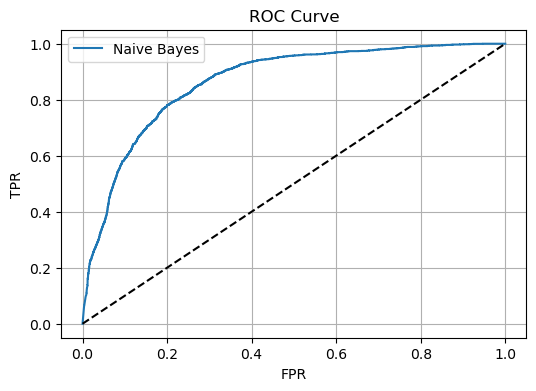

ROC-AUC Score: 0.8650863962377677


In [8]:
# 11. ROC Curve
y_prob = nb_final.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="Naive Bayes")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.grid()
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))